# Strategic Productivity & Digital Behavior Insights

### Objective
This project aims to analyze the correlation between social media usage patterns and study habits to design data-driven strategies for optimizing personal productivity. It enables users to understand the impact of their digital habits and implement more effective time management techniques.

### Step 1: Import Necessary Libraries
In this initial phase, we import the essential Python libraries required for data manipulation, visualization, and machine learning preprocessing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

##### Data Loading

In [ ]:
df = pd.read_csv("social_media_productivity.csv")

### Step 2: Data Inspection
- The `head()` function is used to preview the first five rows of the dataset, providing a quick overview of the data structure and content.

In [ ]:
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


- The `describe()` function generates a statistical summary of numerical columns (e.g., mean, standard deviation, min, max), providing a quick overview of the data distribution.

In [ ]:
df.describe()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,58.560000
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,100.000000


- `info()` displays dataset structure, data types, and missing values.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 422.0 KB


- Displays the final number of rows and columns in the cleaned dataset.

In [ ]:
df.shape

(6000, 9)

- Counts the number of distinct values in each column to assess categorical diversity and data cardinality.

In [ ]:
df.nunique()

age                        25
daily_screen_time        1000
social_media_hours        923
study_hours               801
sleep_hours               501
notifications_per_day     280
focus_score              1326
addiction_level             3
productivity_score       3830
dtype: int64

### Step 3: Data Cleaning

- Identifies the count of missing (null) values in each column to determine necessary data cleaning steps.

In [ ]:
df.isnull().sum()

age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64

- Checks for non-integer values in the 'age' column and counts their occurrences.

In [ ]:
df['age'].apply(lambda x: x % 1 != 0).value_counts()

age
False    5880
True      120
Name: count, dtype: int64

- Removes rows where 'age' information is missing to ensure data consistency.

In [ ]:
df.dropna(subset=['age'], inplace=True)

- Fills missing values in 'daily_screen_time' with the column's mean.

In [ ]:
df['daily_screen_time'] = df['daily_screen_time'].fillna(df['daily_screen_time'].mean())

- Fills missing values in all specified columns using their respective mean values for consistent data handling.

In [ ]:
filling_cols = ['daily_screen_time', 'social_media_hours', 'study_hours', 'sleep_hours', 'notifications_per_day', 'focus_score', 'productivity_score']
for col in filling_cols:
    df[col] = df[col].fillna(df[col].mean())

- Fills missing values in the 'addiction_level' column with the mode (the most frequent value) to maintain category distribution.

In [ ]:
df['addiction_level'] = df['addiction_level'].fillna(df['addiction_level'].mode()[0])

- Re-checking null values to confirm that all missing data has been successfully handled.

In [ ]:
df.isnull().sum()

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64

- Checks the dataset for duplicate rows and returns the total count of identified duplicates.

In [ ]:
df.duplicated().sum()

np.int64(0)

### Outlier Detection
- This code visualizes the distribution and identifies potential outliers for the selected columns using a boxplot.

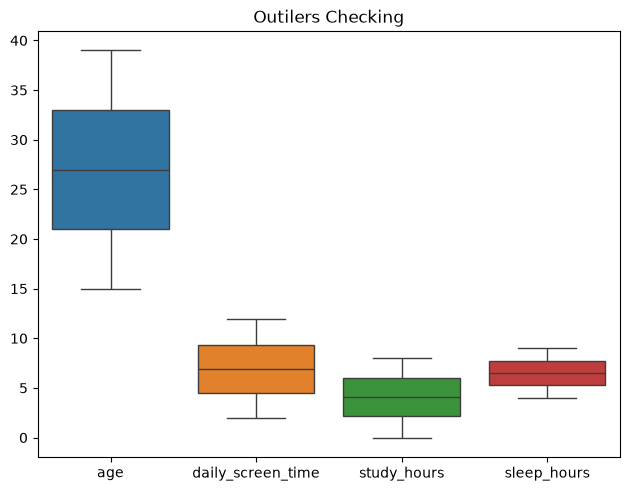

In [ ]:
column=['age','daily_screen_time','study_hours','sleep_hours']
sns.boxplot(data=df[column])
plt.tight_layout()
plt.title("Outilers Checking")
plt.show()

- This code visualizes the distribution and identifies potential outliers for the productivity_score and notifications_per_day columns using a boxplot.

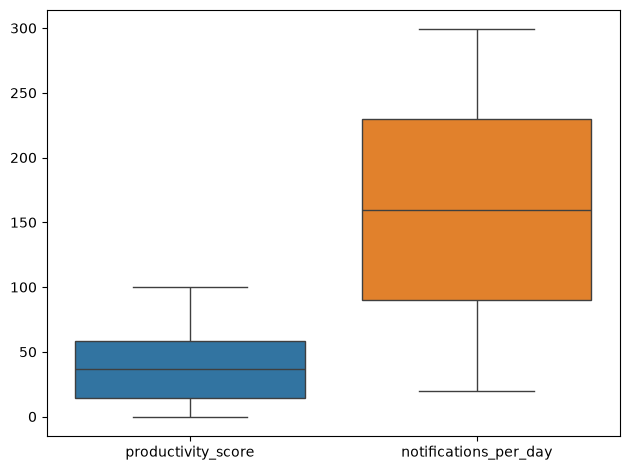

In [ ]:
col2 = ['productivity_score','notifications_per_day']
sns.boxplot(data=df[col2])
plt.tight_layout()
plt.show()

- This code visualizes the focus_score column to identify potential outliers using a boxplot.

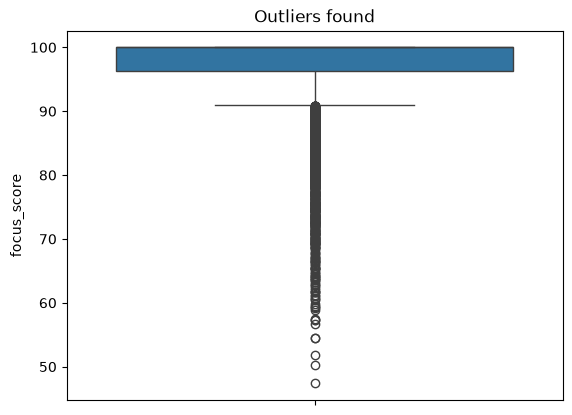

In [ ]:
sns.boxplot(df['focus_score'])
plt.title("Outliers found")
plt.show()

- The clipping operation has been applied to focus_score to constrain values within the $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$ range.

In [ ]:
Q1 = df['focus_score'].quantile(0.25)
Q3 = df['focus_score'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['focus_score'] = df['focus_score'].clip(lower=lower_bound, upper=upper_bound)

- This step creates a boxplot to verify that the outliers in focus_score have been successfully capped.

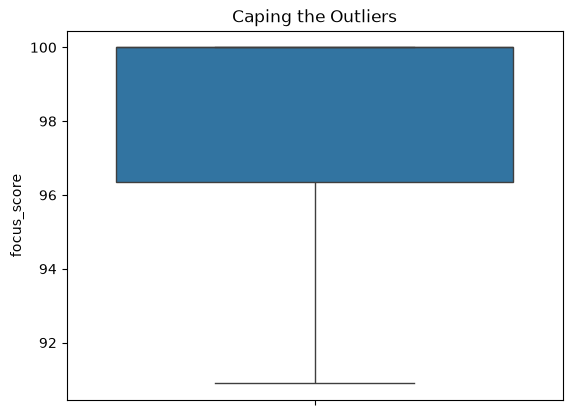

In [ ]:
sns.boxplot(df['focus_score'])
plt.title("Caping the Outliers")
plt.show()

- This code visualizes the social_media_hours column to identify potential outliers using a boxplot.

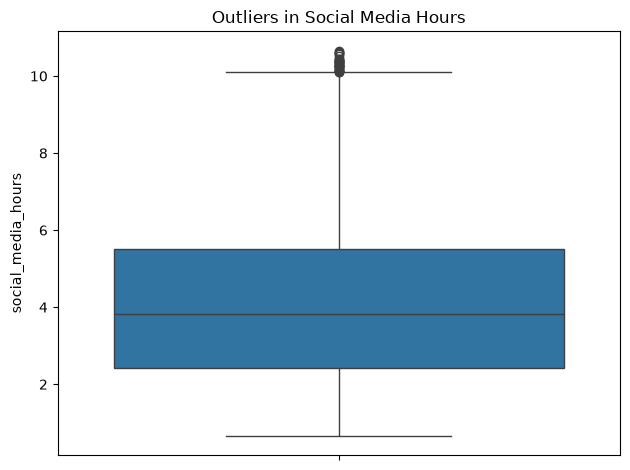

In [ ]:
sns.boxplot(df['social_media_hours'])
plt.title("Outliers in Social Media Hours")
plt.tight_layout()
plt.show()

- TThe analysis identifies 31 outliers in social_media_hours. Given that this represents a small proportion of the total dataset, we are choosing to ignore them to maintain the integrity of the remaining data distribution.

In [ ]:
# IQR method se outliers check karna
Q1 = df['social_media_hours'].quantile(0.25)
Q3 = df['social_media_hours'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['social_media_hours'] > (Q3 + 1.5 * IQR))]
print("Total outliers in social_media_hours:", len(outliers))

Total outliers in social_media_hours: 31


### Step 4: Data Visualization

- This code generates a Kernel Density Estimate (KDE) plot to visualize the probability density function of the study_hours column, helping to identify the distribution shape.

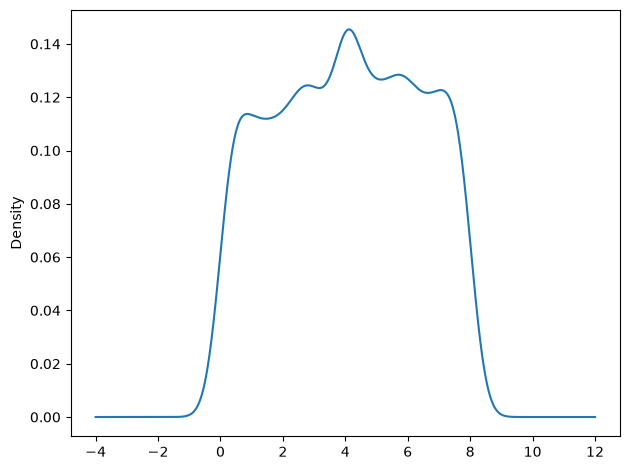

In [ ]:
df['study_hours'].plot(kind='kde')
plt.tight_layout()
plt.show()

$Correlation Analysis: (HeatMap)$
- This code calculates the correlation matrix for numerical columns and visualizes it using a heatmap, which helps in identifying relationships between variables.

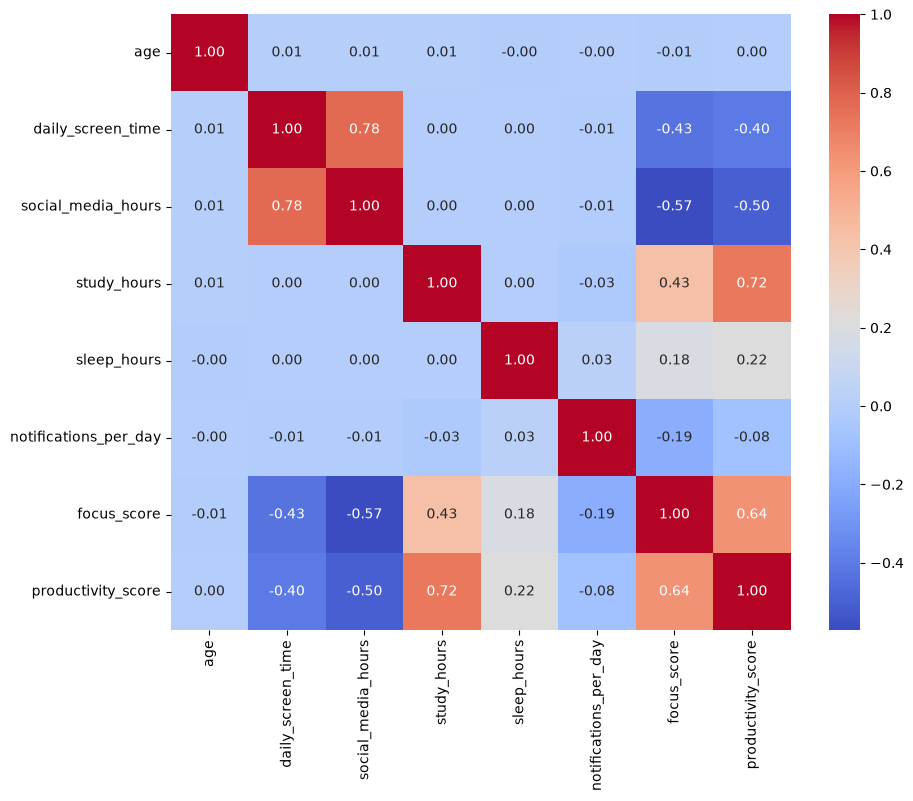

In [ ]:
plt.figure(figsize=(10,8))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

- This code creates a regression plot to visualize the linear relationship between study_hours and productivity_score. The shaded area represents the confidence interval, while the line indicates the trend.

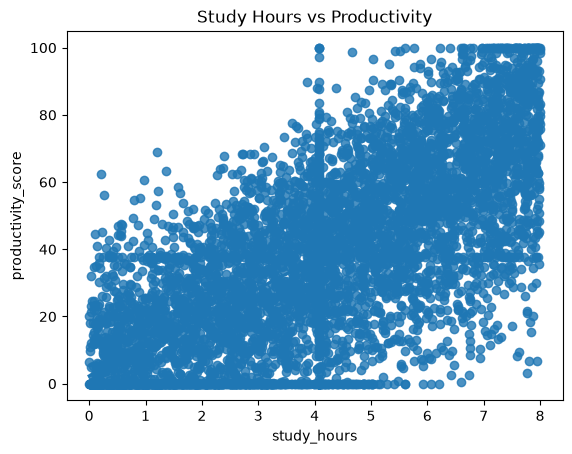

In [ ]:
sns.regplot(x='study_hours', y='productivity_score', data=df)
plt.title('Study Hours vs Productivity')
plt.show()

- This scatterplot visualizes the relationship between social_media_hours and productivity_score. It helps identify whether there is a correlation (positive, negative, or none) between time spent on social media and user productivity.

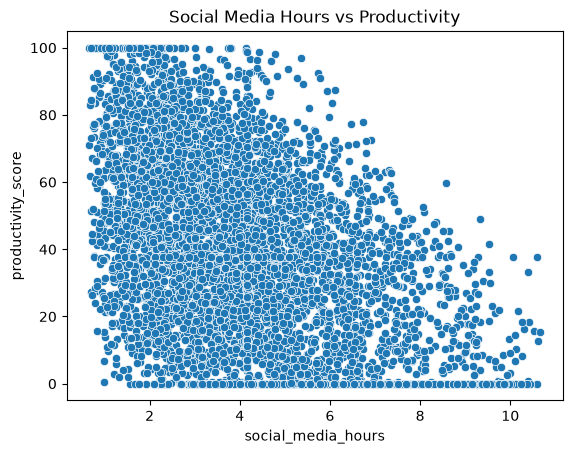

In [ ]:
sns.scatterplot(x='social_media_hours', y='productivity_score', data=df)
plt.title('Social Media Hours vs Productivity')
plt.show()

- This code generates a bar chart to visualize the distribution of different addiction levels, allowing you to quickly see the frequency of each category within your dataset.

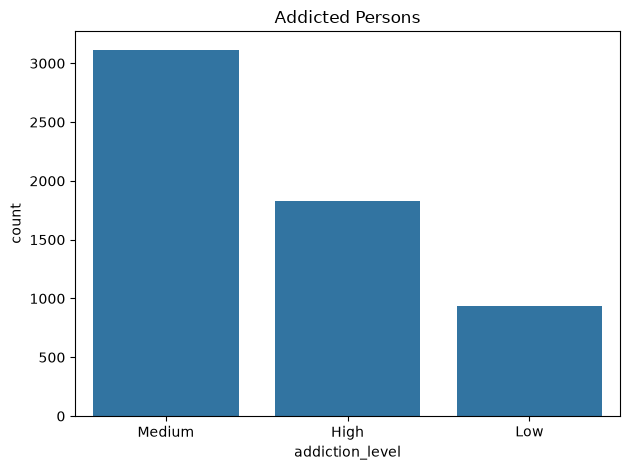

In [ ]:
sns.barplot(df['addiction_level'].value_counts())
plt.tight_layout()
plt.title('Addicted Persons')
plt.tight_layout()
plt.show()

- This code creates a pie chart representing the top 5 most frequently occurring sleep durations in your dataset, providing a clear visual breakdown of how these specific durations compare to one another.

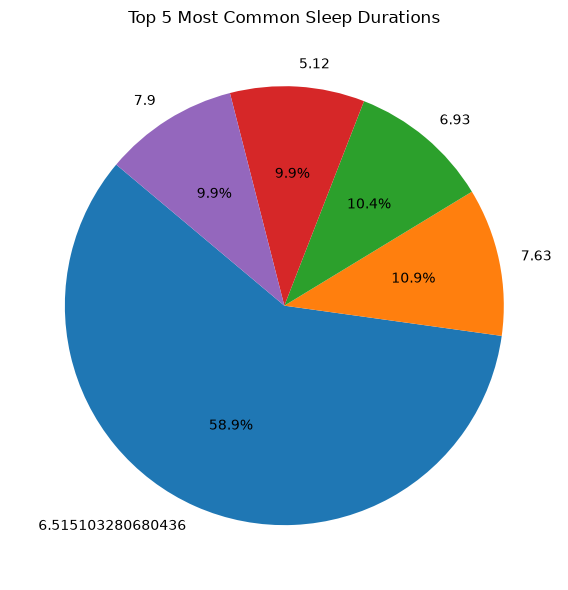

In [ ]:
a = df['sleep_hours'].value_counts()
s = a.head()
plt.figure(figsize=(8, 6))
plt.pie(s, labels=s.index, autopct="%1.1f%%", startangle=140)
plt.title('Top 5 Most Common Sleep Durations')
plt.tight_layout()
plt.show()


- This code extracts the records of individuals categorized with 'High' addiction levels and generates a pie chart showing the distribution of the top 5 age groups within that category. This helps in pinpointing which age demographic is most prone to high addiction levels.

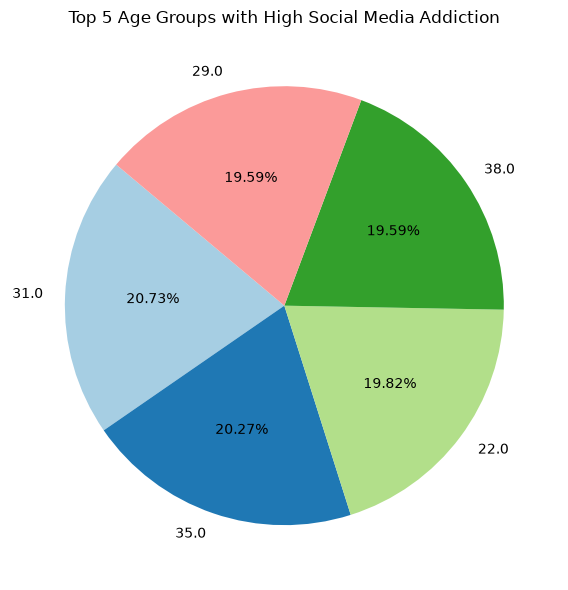

In [ ]:
addic = df[df['addiction_level'] == 'High']
top = addic['age'].value_counts().head()
plt.figure(figsize=(8, 6))
plt.pie(top, labels=top.index, autopct="%1.2f%%", startangle=140, colors=plt.cm.Paired.colors)
plt.title('Top 5 Age Groups with High Social Media Addiction')
plt.tight_layout()
plt.show()

- This code calculates the average daily_screen_time for each age group and visualizes the top 5 ages with the highest usage in a bar chart to identify segments with the highest digital consumption.

C:\Users\DELL\AppData\Local\Temp\ipykernel_13584\1384712034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=screen.index, y=screen.values, palette='viridis')


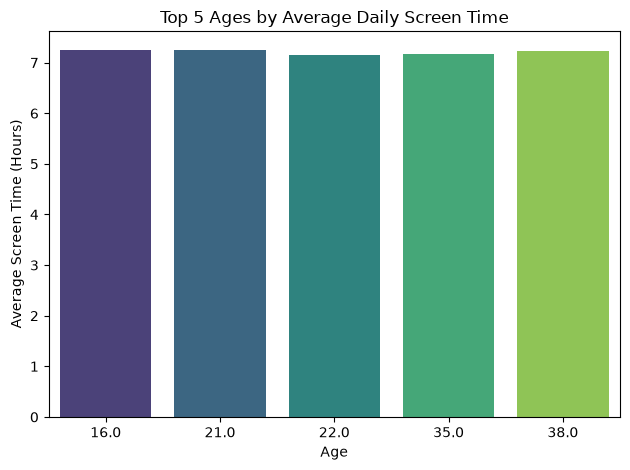

In [ ]:
screen = df.groupby('age')['daily_screen_time'].mean().sort_values(ascending=False).head()
sns.barplot(x=screen.index, y=screen.values, palette='viridis')
plt.title("Top 5 Ages by Average Daily Screen Time")
plt.xlabel("Age")
plt.ylabel("Average Screen Time (Hours)")
plt.tight_layout()
plt.show()

### Step 4: Feature Engineering
- This code uses LabelEncoder to convert categorical text data in the addiction_level column (such as 'Low', 'Moderate', 'High') into a machine-readable numerical format (e.g., 0, 1, 2).

In [ ]:
le = LabelEncoder()
df['addiction_level'] = le.fit_transform(df['addiction_level'])

### Step 5: Feature Scaling
- This code standardizes the selected numerical columns by scaling them to have a mean of 0 and a standard deviation of 1, which ensures that features with different ranges do not bias machine learning models.

In [ ]:
scaler = StandardScaler()
cols = ['age','daily_screen_time','social_media_hours','study_hours','sleep_hours','notifications_per_day','focus_score']
df[cols] = scaler.fit_transform(df[cols])

### Step 6: Final Insights: Social Media & Productivity Analysis
- `Positive Determinants of Productivity:` There is a strong positive correlation between study_hours and productivity_score (0.72). Increasing time spent on academic activities is the most effective way to boost productivity.

- `Impact of Focus:` focus_score has a significant positive influence (0.64) on overall output, confirming that concentration quality is just as important as the total time spent studying.

- `Primary Productivity Inhibitors:` A clear inverse relationship exists between social_media_hours and productivity (-0.50). Excessive digital consumption consistently correlates with a decline in performance metrics.

- `Digital Saturation:` High daily_screen_time (-0.40) negatively affects the productivity_score, suggesting that prolonged screen exposure leads to reduced mental efficiency.

- `Demographic Targeting:` Analysis identified specific age segments with "High" addiction levels, which serves as a critical indicator for targeted focus-management interventions.

- `Data Integrity:` The preprocessing steps, including outlier removal (31 instances) and feature scaling, have ensured that the dataset is mathematically robust and reliable for predictive modeling.

- `Recommendations for Improvement:` To maximize productivity, users should focus on "digital detox" strategies, reducing non-essential screen time, and maintaining structured, high-focus study periods.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Defining Features (X) and Target (y)
# Yahan 'addiction_level' ko hum predict karna chahte hain
X = df.drop('addiction_level', axis=1)
y = df['addiction_level']

# 2. Splitting into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (4704, 8)
Testing set shape: (1176, 8)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test)

# 4. Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 98.47%

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       362
           1       0.99      0.99      0.99       183
           2       0.99      0.98      0.99       631

    accuracy                           0.98      1176
   macro avg       0.98      0.99      0.99      1176
weighted avg       0.98      0.98      0.98      1176



C:\Users\DELL\AppData\Local\Temp\ipykernel_13584\3022338648.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


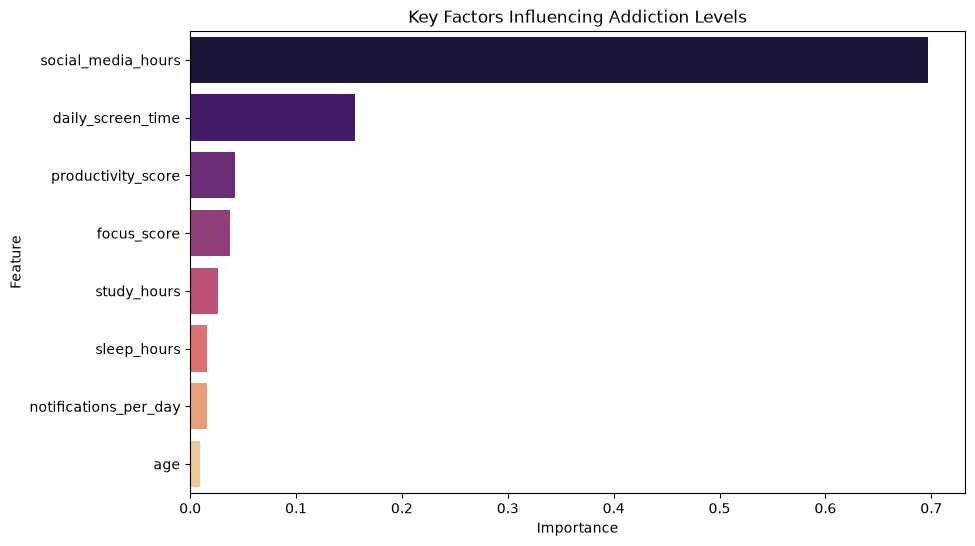

In [ ]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort karna taake sabse important upar aaye
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title("Key Factors Influencing Addiction Levels")
plt.show()

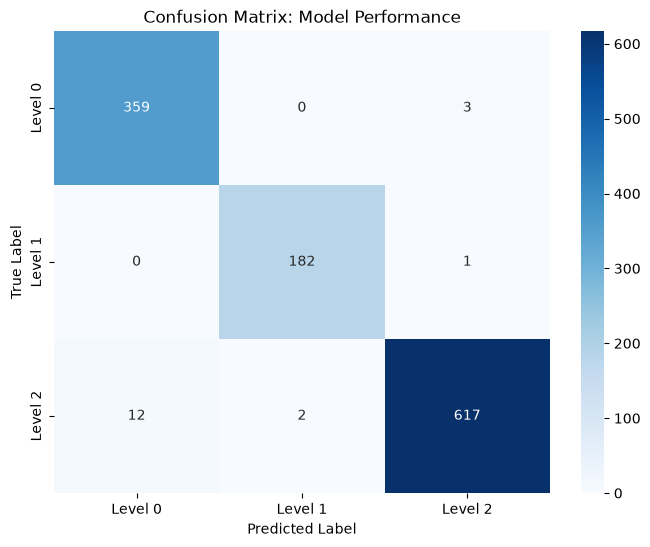

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Level 0', 'Level 1', 'Level 2'], 
            yticklabels=['Level 0', 'Level 1', 'Level 2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Model Performance')
plt.show()

In [ ]:
import joblib

# Model ko save karein
joblib.dump(model, 'addiction_model.pkl')
print("Model successfully saved!")

Model successfully saved!
